# Experiment: Landmark-count sweep (L-sweep)

Cylindrical arena, landmark count `L ∈ {0, 1, 2, 4, 8}`, rotation `φ ∈ {0°, 30°, 60°, 90°, 120°, 180°}`.

Place cells are formed **once** by clustering visual features at `L=8, φ=0` and held fixed across all conditions.
Per cell we measure the angular shift `Δθ` of the activation-weighted field centroid between the rotated and baseline conditions.

Reported per `(L, φ)`:

- mean `Δθ` (predicted ≈ `φ`)
- coherence `R` (mean resultant length across cells)
- V-test against predicted direction `φ`
- slope-1 regression of mean `Δθ` on `φ` within each `L`

`L=0` is analyzed separately — null angular tuning at fixed radius, plus separate radial vs. angular decoding.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os
os.chdir('../..')  # project root

import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

plt.style.use('default')
mpl.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'savefig.facecolor': 'white',
})

from realm_tools.experiment_lib.loggers import PovDataset, combine_pov_observations
from realm_tools.place_cell_lib import fit_gmm, VisualPlaceCellEnsemble

## Config

In [2]:
L_VALUES   = [0, 1, 2, 4, 8]
PHI_VALUES = [0, 30, 60, 90, 120, 180]

N_CELLS    = 750
REG_COVAR  = 1e-3
N_COMBINE  = 8              # collapse all headings at each location
RANDOM_SEED = 0

DATA_DIR = 'data/vpce/collect_data'
SAVE_DIR = 'analysis/experiment_landmark_count_sweep/figures'
os.makedirs(SAVE_DIR, exist_ok=True)

def data_path(L, phi):
    if L == 0:
        return f'{DATA_DIR}/circ_lm0.h5'
    return f'{DATA_DIR}/circ_lm{L}_r{phi}.h5'

def savefig(name):
    p = os.path.join(SAVE_DIR, name)
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    print(f'Saved → {p}')

## Helpers

In [3]:
def load_condition(L, phi):
    """Load a PovDataset, collapse all 8 headings per location, return (features, xy)."""
    ds       = PovDataset.load_dataset(data_path(L, phi))
    combined = combine_pov_observations(ds, n_combine=N_COMBINE)
    features = np.asarray(combined['multimodal_features'])
    xy       = np.stack([combined['x'], combined['y']], axis=1)
    return features, xy


def wrap_pi(a):
    """Wrap angles (radians) to (-π, π]."""
    return (a + np.pi) % (2 * np.pi) - np.pi


def field_centroid_angle(activations, xy):
    """Per-cell activation-weighted (x, y) centroid → θ ∈ (-π, π].

    Parameters
    ----------
    activations : (N, K)  place-cell activations at N locations.
    xy          : (N, 2)  arena positions, assumed centered on (0, 0).

    Returns
    -------
    theta : (K,) angle of the weighted centroid, atan2(y_c, x_c)
    r     : (K,) radius of the weighted centroid (m); useful for QC / L=0.
    """
    w    = activations                       # (N, K)
    wsum = w.sum(axis=0)                     # (K,)
    wsum = np.where(wsum > 0, wsum, 1.0)
    xc   = (w * xy[:, 0:1]).sum(axis=0) / wsum
    yc   = (w * xy[:, 1:2]).sum(axis=0) / wsum
    return np.arctan2(yc, xc), np.hypot(xc, yc)


def circ_mean(angles):
    """Mean angle of a set of angles (radians), in (-π, π]."""
    return np.arctan2(np.sin(angles).mean(), np.cos(angles).mean())


def circ_R(angles):
    """Mean resultant length (coherence) of a set of angles."""
    return float(np.hypot(np.sin(angles).mean(), np.cos(angles).mean()))


def v_test(angles, mu0):
    """Modified Rayleigh (V) test — H0: uniform vs H1: unimodal at μ0.

    Returns (V, u, p) where u ~ N(0, 1) under H0 and p is one-sided.
    """
    n = len(angles)
    if n == 0:
        return np.nan, np.nan, np.nan
    R    = circ_R(angles)
    mean = circ_mean(angles)
    V    = R * np.cos(mean - mu0)
    u    = V * np.sqrt(2 * n)
    # one-sided p-value (large u → reject uniform in favour of concentration at μ0)
    from math import erfc, sqrt
    p    = 0.5 * erfc(u / sqrt(2))
    return float(V), float(u), float(p)


def rayleigh_test(angles):
    """Rayleigh test — H0: uniform. Returns (R, Z, p)."""
    n = len(angles)
    R = circ_R(angles)
    Z = n * R ** 2
    # Zar (1999) approximation
    p = np.exp(np.sqrt(1 + 4 * n + 4 * (n ** 2 - (n * R) ** 2)) - (1 + 2 * n))
    return float(R), float(Z), float(p)

## Baseline fit — place cells from L=8, φ=0

GMM with `K=750` on the collapsed-headings features. These cells are frozen and reused for every subsequent condition.

In [4]:
features_base, xy_base = load_condition(L=8, phi=0)
print(f'Baseline observations : {features_base.shape[0]}')
print(f'Feature dim           : {features_base.shape[1]}')

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    centers, radii = fit_gmm(
        features_base,
        n_components=N_CELLS,
        reg_covar=REG_COVAR,
        random_state=RANDOM_SEED,
    )

ensemble = VisualPlaceCellEnsemble(centers, radii)
print(f'Fit ensemble: K={ensemble.n_cells}  D={ensemble.feature_dim}')

act_base                 = ensemble.activate(features_base)      # (N, K)
theta_base, r_base       = field_centroid_angle(act_base, xy_base)
print(f'Baseline centroid radii — min {r_base.min():.3f}  mean {r_base.mean():.3f}  max {r_base.max():.3f}')

Baseline observations : 6919
Feature dim           : 7364
Fit ensemble: K=750  D=7364
Baseline centroid radii — min 0.015  mean 0.519  max 2.316


## Sweep — activate the frozen ensemble on every (L, φ)

For each condition we compute the per-cell centroid angle and the per-cell shift `Δθ = wrap(θ - θ_base)`.
L=0 is loaded once and shared across φ (no landmarks → rotation is trivially identity).

In [5]:
per_cell_records = []   # (L, phi, cell, dtheta, theta, r)

for L in L_VALUES:
    phi_list = [0] if L == 0 else PHI_VALUES
    for phi in phi_list:
        features, xy   = load_condition(L, phi)
        act            = ensemble.activate(features)
        theta, r_cent  = field_centroid_angle(act, xy)
        dtheta         = wrap_pi(theta - theta_base)

        for k in range(N_CELLS):
            per_cell_records.append({
                'L'      : L,
                'phi'    : phi,
                'cell'   : k,
                'theta'  : float(theta[k]),
                'r_cent' : float(r_cent[k]),
                'dtheta' : float(dtheta[k]),
            })

        print(f'L={L}  φ={phi:>3d}°   |Δθ| median = {np.rad2deg(np.median(np.abs(dtheta))):6.2f}°   R = {circ_R(dtheta):.3f}')

per_cell = pd.DataFrame(per_cell_records)
per_cell.to_csv(os.path.join(SAVE_DIR, 'per_cell_dtheta.csv'), index=False)
print(f'\nSaved per-cell records: {len(per_cell)} rows')

L=0  φ=  0°   |Δθ| median =  44.16°   R = 0.271
L=1  φ=  0°   |Δθ| median = 116.52°   R = 0.463
L=1  φ= 30°   |Δθ| median = 139.64°   R = 0.493
L=1  φ= 60°   |Δθ| median = 153.65°   R = 0.442
L=1  φ= 90°   |Δθ| median = 128.47°   R = 0.428
L=1  φ=120°   |Δθ| median = 104.54°   R = 0.466
L=1  φ=180°   |Δθ| median =  60.25°   R = 0.478
L=2  φ=  0°   |Δθ| median =  43.79°   R = 0.475
L=2  φ= 30°   |Δθ| median =  72.80°   R = 0.500
L=2  φ= 60°   |Δθ| median =  94.88°   R = 0.495
L=2  φ= 90°   |Δθ| median = 115.72°   R = 0.452
L=2  φ=120°   |Δθ| median = 136.05°   R = 0.436
L=2  φ=180°   |Δθ| median = 128.91°   R = 0.414
L=4  φ=  0°   |Δθ| median =  41.80°   R = 0.642
L=4  φ= 30°   |Δθ| median =  56.12°   R = 0.626
L=4  φ= 60°   |Δθ| median =  75.63°   R = 0.585
L=4  φ= 90°   |Δθ| median =  83.51°   R = 0.586
L=4  φ=120°   |Δθ| median = 108.56°   R = 0.297
L=4  φ=180°   |Δθ| median =  61.67°   R = 0.361
L=8  φ=  0°   |Δθ| median =   0.00°   R = 1.000
L=8  φ= 30°   |Δθ| median =  30.06°   R 

## (L, φ) directional statistics

For each `(L, φ)` compute:

- `mean_dtheta` — circular mean of Δθ across cells (deg)
- `R`          — mean resultant length across cells
- `V`, `u`, `p_V` — V-test against predicted direction `φ`

L=0 rows use predicted direction `0°` (null).

In [6]:
summary_rows = []
for (L, phi), g in per_cell.groupby(['L', 'phi'], sort=False):
    ang       = g['dtheta'].to_numpy()
    mu0       = np.deg2rad(phi)
    V, u, pV  = v_test(ang, mu0)
    summary_rows.append({
        'L'              : L,
        'phi_deg'        : phi,
        'n_cells'        : len(ang),
        'mean_dtheta_deg': np.rad2deg(circ_mean(ang)),
        'R'              : circ_R(ang),
        'V'              : V,
        'u'              : u,
        'p_V'            : pV,
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(os.path.join(SAVE_DIR, 'lphi_summary.csv'), index=False)

fmt = {
    'mean_dtheta_deg': '{:7.2f}'.format,
    'R'              : '{:.3f}'.format,
    'V'              : '{:.3f}'.format,
    'u'              : '{:6.2f}'.format,
    'p_V'            : '{:.2e}'.format,
}
print('── (L, φ) directional statistics ──')
print(summary.to_string(index=False, formatters=fmt))

── (L, φ) directional statistics ──
 L  phi_deg  n_cells mean_dtheta_deg     R      V      u       p_V
 0        0      750           -1.27 0.271  0.271  10.51  3.79e-26
 1        0      750          129.41 0.463 -0.294 -11.39  1.00e+00
 1       30      750          159.72 0.493 -0.315 -12.19  1.00e+00
 1       60      750         -169.70 0.442 -0.286 -11.08  1.00e+00
 1       90      750         -143.42 0.428 -0.255  -9.88  1.00e+00
 1      120      750         -112.16 0.466 -0.286 -11.07  1.00e+00
 1      180      750          -57.98 0.478 -0.254  -9.83  1.00e+00
 2        0      750           34.17 0.475  0.393  15.23  1.21e-52
 2       30      750           69.90 0.500  0.384  14.86  3.22e-50
 2       60      750           96.26 0.495  0.399  15.47  2.66e-54
 2       90      750          121.94 0.452  0.384  14.86  2.89e-50
 2      120      750          155.10 0.436  0.356  13.80  1.21e-43
 2      180      750         -139.99 0.414  0.317  12.29  4.90e-35
 4        0      750      

### Mean Δθ vs φ per L (with slope-1 reference)

Under a rigid rotation of the landmark array we expect `mean Δθ ≈ φ` for L ≥ 1.

Saved → analysis/experiment_landmark_count_sweep/figures/mean_dtheta_vs_phi.png


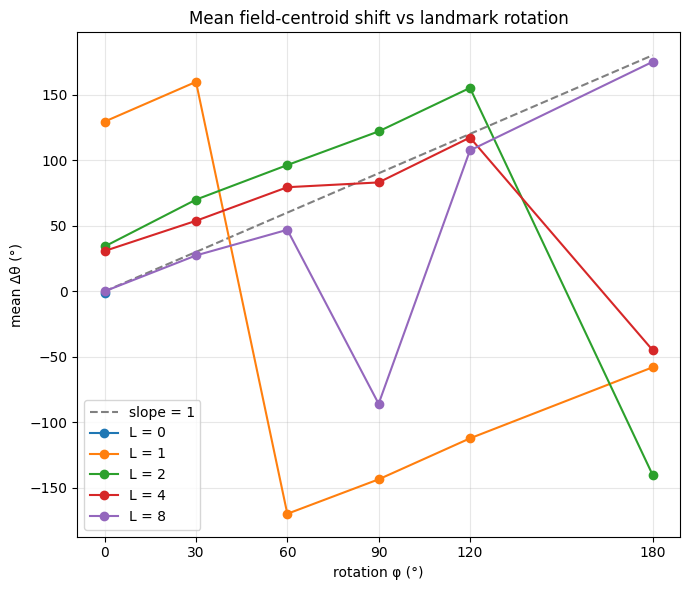

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
phi_line = np.array([0, 180])
ax.plot(phi_line, phi_line, ls='--', color='gray', label='slope = 1')

for L in L_VALUES:
    sub = summary[summary['L'] == L].sort_values('phi_deg')
    ax.plot(sub['phi_deg'], sub['mean_dtheta_deg'], marker='o', label=f'L = {L}')

ax.set_xlabel('rotation φ (°)')
ax.set_ylabel('mean Δθ (°)')
ax.set_title('Mean field-centroid shift vs landmark rotation')
ax.set_xticks(PHI_VALUES)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig('mean_dtheta_vs_phi.png')
plt.show()

### Coherence R vs φ per L

`R` close to 1 means cells shift *together*; low `R` means the population is scrambled (remapping).

Saved → analysis/experiment_landmark_count_sweep/figures/coherence_R_vs_phi.png


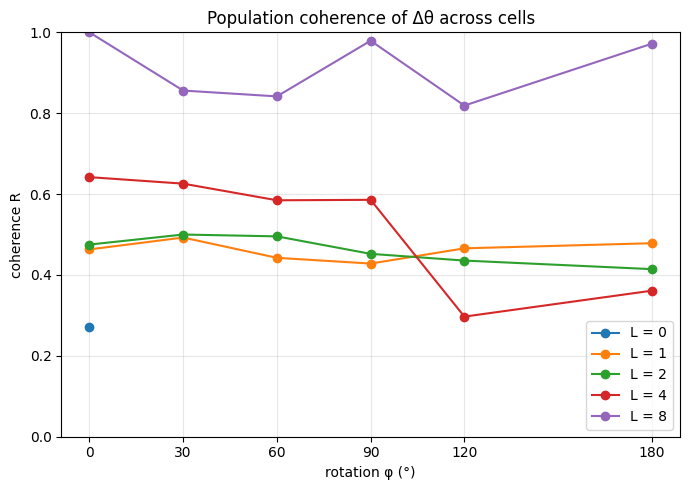

In [8]:
fig, ax = plt.subplots(figsize=(7, 5))
for L in L_VALUES:
    sub = summary[summary['L'] == L].sort_values('phi_deg')
    ax.plot(sub['phi_deg'], sub['R'], marker='o', label=f'L = {L}')
ax.set_xlabel('rotation φ (°)')
ax.set_ylabel('coherence R')
ax.set_title('Population coherence of Δθ across cells')
ax.set_xticks(PHI_VALUES)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
savefig('coherence_R_vs_phi.png')
plt.show()

### Slope-1 regression of mean Δθ on φ per L

For each L we regress `mean_dtheta_deg` on `phi_deg` (OLS through origin? no — free intercept) and report the fitted slope, intercept, and R².

In [9]:
reg_rows = []
for L in L_VALUES:
    sub = summary[summary['L'] == L].sort_values('phi_deg')
    if len(sub) < 2:
        continue
    x = sub['phi_deg'].to_numpy(dtype=float)
    y = sub['mean_dtheta_deg'].to_numpy(dtype=float)
    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x + intercept
    ss_res = np.sum((y - y_hat) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2) if len(y) > 1 else np.nan
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    reg_rows.append({
        'L'          : L,
        'slope'      : slope,
        'intercept'  : intercept,
        'r_squared'  : r2,
        'slope_err_from_1': slope - 1.0,
    })

regression = pd.DataFrame(reg_rows)
regression.to_csv(os.path.join(SAVE_DIR, 'slope1_regression.csv'), index=False)

print('── Slope-1 regression of mean Δθ on φ per L ──')
print(regression.to_string(index=False, formatters={
    'slope'           : '{:.3f}'.format,
    'intercept'       : '{:.2f}'.format,
    'r_squared'       : '{:.3f}'.format,
    'slope_err_from_1': '{:+.3f}'.format,
}))

── Slope-1 regression of mean Δθ on φ per L ──
 L  slope intercept r_squared slope_err_from_1
 1 -1.270     69.22     0.334           -2.270
 2 -0.701    112.35     0.188           -1.701
 4 -0.271     74.93     0.098           -1.271
 8  0.887    -25.84     0.411           -0.113


## L = 0 — angular modulation and separate radial / angular decoding

With no landmarks the visual features carry only radial (distance-to-wall) information — predicted null angular tuning.
We evaluate two things:

1. **Angular-modulation test at fixed radius** — Rayleigh test on the centroid angles of cells whose centroids fall in a narrow ring near the mean radius. Under the null we expect uniformity.
2. **Radial vs angular decoding** — fit a linear decoder on the population activation to predict `(x, y)`, split into train / test, then report mean errors in radius vs angle separately.

Predicted: radial error small, angular error large (≈ chance for a uniform circle).

In [10]:
features_L0, xy_L0 = load_condition(L=0, phi=0)
act_L0             = ensemble.activate(features_L0)
theta_L0, r_L0     = field_centroid_angle(act_L0, xy_L0)

# Angular-modulation test — cells whose centroids sit in a narrow ring near the median
r_med   = float(np.median(r_L0))
band    = 0.10 * r_med    # ±10% ring
in_ring = (r_L0 >= r_med - band) & (r_L0 <= r_med + band)
R_ring, Z_ring, p_ring = rayleigh_test(theta_L0[in_ring])
print(f'Ring test: r ∈ [{r_med - band:.3f}, {r_med + band:.3f}] m  ({int(in_ring.sum())} cells)')
print(f'  Rayleigh R = {R_ring:.3f}   Z = {Z_ring:.2f}   p = {p_ring:.3g}')

# All-cell test (no radius band) for reference
R_all, Z_all, p_all = rayleigh_test(theta_L0)
print(f'All cells    : R = {R_all:.3f}   Z = {Z_all:.2f}   p = {p_all:.3g}')

Ring test: r ∈ [0.064, 0.078] m  (79 cells)
  Rayleigh R = 0.767   Z = 46.50   p = 4.27e-25
All cells    : R = 0.688   Z = 355.25   p = 2.16e-179


Saved → analysis/experiment_landmark_count_sweep/figures/L0_centroid_angle_hist.png


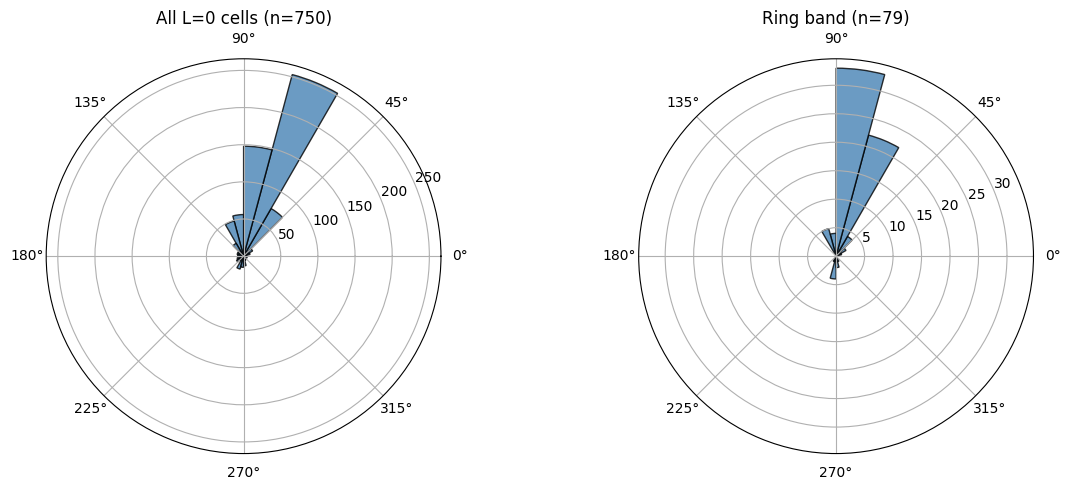

In [11]:
# Distribution of centroid angles at L=0 — visual check of angular uniformity
fig, ax = plt.subplots(1, 2, figsize=(12, 5), subplot_kw={'projection': 'polar'})
bins = np.linspace(-np.pi, np.pi, 25)

for a, angles, title in zip(ax,
                            [theta_L0, theta_L0[in_ring]],
                            [f'All L=0 cells (n={N_CELLS})', f'Ring band (n={int(in_ring.sum())})']):
    counts, _ = np.histogram(angles, bins=bins)
    centers   = 0.5 * (bins[:-1] + bins[1:])
    width     = bins[1] - bins[0]
    a.bar(centers, counts, width=width, edgecolor='black', color='steelblue', alpha=0.8)
    a.set_title(title)

plt.tight_layout()
savefig('L0_centroid_angle_hist.png')
plt.show()

In [12]:
# Radial vs angular decoding at L=0 — linear decoder on population activation.
rng   = np.random.default_rng(RANDOM_SEED)
N     = len(features_L0)
perm  = rng.permutation(N)
n_tr  = int(0.5 * N)
tr, te = perm[:n_tr], perm[n_tr:]

A_tr, A_te = act_L0[tr], act_L0[te]
XY_tr, XY_te = xy_L0[tr], xy_L0[te]

# Design matrix with intercept
def with_bias(A):
    return np.hstack([A, np.ones((A.shape[0], 1))])

W, *_ = np.linalg.lstsq(with_bias(A_tr), XY_tr, rcond=None)
XY_pred = with_bias(A_te) @ W

r_true, r_pred     = np.hypot(*XY_te.T),   np.hypot(*XY_pred.T)
th_true, th_pred   = np.arctan2(XY_te[:, 1], XY_te[:, 0]), np.arctan2(XY_pred[:, 1], XY_pred[:, 0])

radial_err_m       = np.abs(r_pred - r_true)
angular_err_deg    = np.abs(np.rad2deg(wrap_pi(th_pred - th_true)))

# Chance baselines: predict the mean (r, θ) of the training set, or uniform circle for angle.
r_mean_tr          = np.hypot(*XY_tr.T).mean()
radial_chance      = np.mean(np.abs(np.hypot(*XY_te.T) - r_mean_tr))
angular_chance     = 90.0   # E[|Δθ|] under uniform on (-180, 180]

print('── L=0 decoding errors (mean absolute) ──')
print(f'  Radial  : {radial_err_m.mean():.3f} m    chance ≈ {radial_chance:.3f} m')
print(f'  Angular : {angular_err_deg.mean():.2f}°   chance ≈ {angular_chance:.2f}°')

pd.DataFrame({
    'metric'      : ['radial_err_m', 'angular_err_deg'],
    'decoder'     : [radial_err_m.mean(), angular_err_deg.mean()],
    'chance'      : [radial_chance,       angular_chance],
}).to_csv(os.path.join(SAVE_DIR, 'L0_decoding.csv'), index=False)

── L=0 decoding errors (mean absolute) ──
  Radial  : 0.285 m    chance ≈ 0.462 m
  Angular : 15.41°   chance ≈ 90.00°


Saved → analysis/experiment_landmark_count_sweep/figures/L0_decoding_errors.png


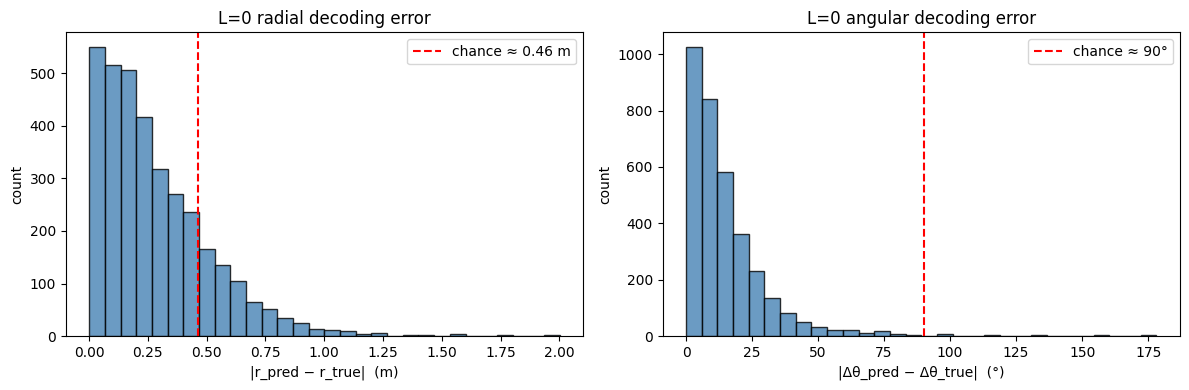

In [13]:
# Visual comparison — histograms of per-observation decoding error
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(radial_err_m, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax[0].axvline(radial_chance, ls='--', color='red', label=f'chance ≈ {radial_chance:.2f} m')
ax[0].set_xlabel('|r_pred − r_true|  (m)')
ax[0].set_ylabel('count')
ax[0].set_title('L=0 radial decoding error')
ax[0].legend()

ax[1].hist(angular_err_deg, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
ax[1].axvline(angular_chance, ls='--', color='red', label=f'chance ≈ {angular_chance:.0f}°')
ax[1].set_xlabel('|Δθ_pred − Δθ_true|  (°)')
ax[1].set_ylabel('count')
ax[1].set_title('L=0 angular decoding error')
ax[1].legend()

plt.tight_layout()
savefig('L0_decoding_errors.png')
plt.show()